
# Exact Values

PyKrige demonstration and usage
as a non-exact interpolator in 1D. 


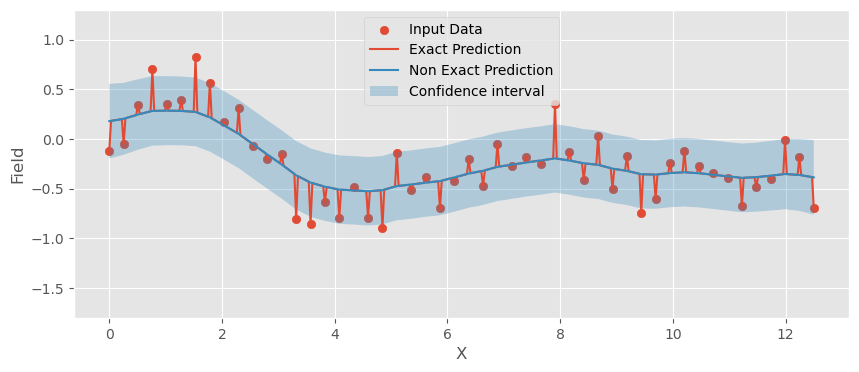

In [3]:
import matplotlib.pyplot as plt
import numpy as np

from pykrige.ok import OrdinaryKriging

plt.style.use("ggplot")

np.random.seed(42)

x = np.linspace(0, 12.5, 50)
xpred = np.linspace(0, 12.5, 393)
y = np.sin(x) * np.exp(-0.25 * x) + np.random.normal(-0.25, 0.25, 50)

# compare OrdinaryKriging as an exact and non exact interpolator
uk = OrdinaryKriging(
    x, np.zeros(x.shape), y, variogram_model="linear", exact_values=False
)
uk_exact = OrdinaryKriging(x, np.zeros(x.shape), y, variogram_model="linear")

y_pred, y_std = uk.execute("grid", xpred, np.array([0.0]), backend="loop")
y_pred_exact, y_std_exact = uk_exact.execute(
    "grid", xpred, np.array([0.0]), backend="loop"
)


y_pred = np.squeeze(y_pred)
y_std = np.squeeze(y_std)

y_pred_exact = np.squeeze(y_pred_exact)
y_std_exact = np.squeeze(y_std_exact)


fig, ax = plt.subplots(1, 1, figsize=(10, 4))

ax.scatter(x, y, label="Input Data")
ax.plot(xpred, y_pred_exact, label="Exact Prediction")
ax.plot(xpred, y_pred, label="Non Exact Prediction")

ax.fill_between(
    xpred,
    y_pred - 3 * y_std,
    y_pred + 3 * y_std,
    alpha=0.3,
    label="Confidence interval",
)
ax.legend(loc=9)
ax.set_ylim(-1.8, 1.3)
ax.legend(loc=9)
plt.xlabel("X")
plt.ylabel("Field")
plt.show()